# Credit Risk Modeling – Probability of Default (PD)
This notebook develops a Probability of Default (PD) model using:

- Weight of Evidence (WOE) transformed variables
- Logistic Regression (statistical, interpretable model)
- Random Forest (machine learning benchmark)

The objective is to estimate the probability that a borrower 
will default within two years (SeriousDlqin2yrs).

The modelling workflow follows regulated banking practices:
- Train/test split performed before transformation
- WOE calculated using training data only
- Identical transformation applied to test data
- Model evaluated using AUC, Gini, and KS statistics


## Modelling Workflow

This notebook follows a structured credit risk modelling approach:

1. Import required libraries  
2. Load WOE-transformed training and test datasets  
3. Define target and feature variables  
4. Build Logistic Regression model (WOE-based) using statsmodels  
5. Evaluate model performance (ROC, AUC, Gini, KS)  
6. Build Random Forest model for performance comparison  
7. Compare model outputs and interpret results  

This separation ensures clarity, reproducibility, and regulatory-style documentation.


## 1️⃣ Import Required Libraries

We import the core libraries required for:

- Data manipulation (pandas, numpy)
- Statistical modelling (statsmodels)
- Machine learning (scikit-learn)
- Model evaluation (ROC, AUC, KS)
- Visualization (matplotlib, seaborn)


In [4]:
# Data handling
import numpy as np
import pandas as pd

# Statistical modelling
import statsmodels.api as sm

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline


## 2️⃣ Load WOE-Transformed Datasets

The datasets used here are already:

- Cleaned  
- Split into train and test  
- Transformed using Weight of Evidence (WOE)  
- Exported after feature engineering  

Using pre-processed datasets ensures:
- No data leakage  
- Consistency between training and testing  
- Separation of preprocessing and modelling logic


In [7]:
train_data = pd.read_csv('../data/processed/pd_model_train_woe.csv')
test_data  = pd.read_csv('../data/processed/pd_model_test_woe.csv')
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (112500, 5)
Test shape: (37500, 5)


## 3️⃣ Define Target Variable and Feature Set

In credit risk modelling:

- The **target variable (y)** represents default behavior  
- The **feature set (X)** contains WOE-transformed predictors  

Separating X and y clearly:
- Improves code clarity  
- Avoids accidental data leakage  
- Makes modelling reproducible and structured


In [8]:
# Define target column name
target_column = "SeriousDlqin2yrs"   # adjust if your column name is slightly different

# Split into features (X) and target (y)
X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]

X_test = test_data.drop(columns=[target_column])
y_test = test_data[target_column]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (112500, 4)
y_train shape: (112500,)


## 4️⃣ Model 1 — Baseline Logistic Regression (Sklearn)

This is a predictive baseline model using:

- WOE-transformed variables
- Logistic Regression from scikit-learn

Purpose:
- Establish baseline performance
- Compare later with statistical model (p-values)
- Compare with Random Forest


In [10]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_reg = LogisticRegression(max_iter=1000)

# Fit model
log_reg.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [11]:
# View coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0]
})

coef_df


,Feature,Coefficient
0,age_woe,-0.769745
1,DPD_30_59_woe,-0.760041
2,DPD_60_89_woe,-0.669019
3,MonthlyIncome_woe,-0.727772


### Model 1 Performance — ROC & AUC
We evaluate out-of-sample predictive performance using:
- ROC Curve
- AUC Score


In [13]:
# Predict probabilities on test set
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)

print("Test AUC:", auc)


Test AUC: 0.7991284140329882


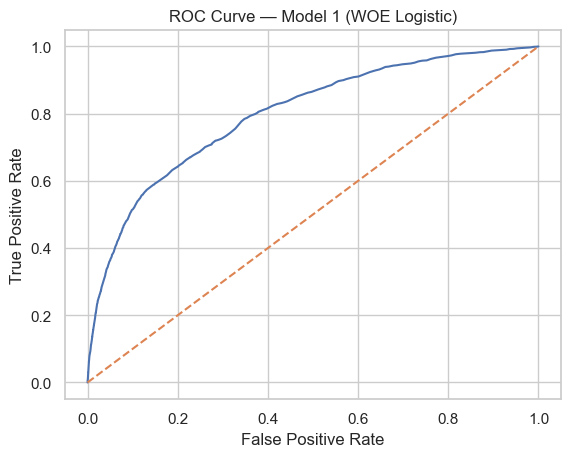

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model 1 (WOE Logistic)")
plt.show()


##Model Discriminatory Power — KS & Gini

In credit risk modelling, performance is not evaluated using accuracy alone.
Banks primarily assess a model’s ranking ability — how well it separates good borrowers from bad borrowers.

Two key industry-standard metrics are:

🔹 Kolmogorov–Smirnov (KS) Statistic

Measures the maximum separation between cumulative distributions of goods and bads

Indicates how effectively the model distinguishes risky borrowers

A KS above 0.30 is generally considered acceptable in retail credit risk

Higher KS → stronger discriminatory power

🔹 Gini Coefficient

Derived from AUC:

Gini=2×AUC−1

Commonly reported in regulatory validation documents

Interpretation:

0.20–0.30 → Weak model

0.30–0.50 → Good model

Above 0.50 → Very strong model

In this section, we calculate:

A quick KS statistic (statistical approach)

A full banking-style KS table with cumulative goods and bads

Gini coefficient derived from AUC

This ensures the model is evaluated using both statistical rigor and banking best practices.

In [15]:
# Gini Coefficient
gini = 2 * auc - 1
print("Gini Coefficient:", round(gini, 4))


Gini Coefficient: 0.5983


In [16]:
from scipy.stats import ks_2samp

# Separate predicted probabilities by class
proba_good = y_pred_proba[y_test == 0]
proba_bad  = y_pred_proba[y_test == 1]

# KS Statistic
ks_stat, ks_pvalue = ks_2samp(proba_good, proba_bad)

print("KS Statistic:", round(ks_stat, 4))


KS Statistic: 0.4443


## Model 2 — Logistic Regression using statsmodels (with Statistical Inference)

In this section, we rebuild the PD model using **statsmodels** instead of sklearn.

Why use statsmodels?

- sklearn focuses on prediction
- statsmodels focuses on statistical inference
- It provides:
  - p-values
  - standard errors
  - z-statistics
  - confidence intervals

This helps us:
- Understand which variables are statistically significant
- Remove weak predictors
- Build a more explainable PD model (important in regulated banking environments)

We use the same WOE-transformed variables as Model 1.


In [17]:
# Import statsmodels for statistical modeling
import statsmodels.api as sm
# Add constant (intercept term) to training data
X_train_sm = sm.add_constant(X_train)

# Also add constant to test data (important for prediction later)
X_test_sm = sm.add_constant(X_test)


In [18]:
# Build logistic regression model using statsmodels
logit_model = sm.Logit(y_train, X_train_sm)

# Fit the model
result = logit_model.fit()

print("Model training completed.")


Optimization terminated successfully.
         Current function value: 0.206349
         Iterations 8
Model training completed.


In [19]:
# Display full statistical summary
print(result.summary())


                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               112500
Model:                          Logit   Df Residuals:                   112495
Method:                           MLE   Df Model:                            4
Date:                Sat, 14 Feb 2026   Pseudo R-squ.:                  0.1591
Time:                        11:37:20   Log-Likelihood:                -23214.
converged:                       True   LL-Null:                       -27607.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.6193      0.013   -194.858      0.000      -2.646      -2.593
age_woe              -0.7663      0.029    -26.258      0.000      -0.823      -0.709
DPD_30_59_woe        -0.

In [20]:
# Create summary dataframe
summary_df = pd.DataFrame({
    "Feature": result.params.index,
    "Coefficient": result.params.values,
    "P_value": result.pvalues.values
})

summary_df


,Feature,Coefficient,P_value
0,const,-2.619349,0.000000e+00
1,age_woe,-0.766268,5.847972e-152
2,DPD_30_59_woe,-0.758794,0.000000e+00
3,DPD_60_89_woe,-0.669293,0.000000e+00
4,MonthlyIncome_woe,-0.726544,1.025881e-51


In [21]:
# Predict probabilities
y_pred_proba_sm = result.predict(X_test_sm)

# Calculate AUC
from sklearn.metrics import roc_auc_score

auc_sm = roc_auc_score(y_test, y_pred_proba_sm)

print("Statsmodels Logistic Test AUC:", round(auc_sm, 4))


Statsmodels Logistic Test AUC: 0.7991


### 📊 Model 2 Interpretation (statsmodels)

All WOE-transformed predictors are statistically significant (p < 0.001).

Observations:

- All coefficients are negative, indicating that higher WOE (safer borrower profile)
  reduces the probability of default.
- Delinquency variables show strong statistical significance,
  consistent with earlier EDA findings.
- Monthly Income remains significant even after WOE transformation.

The model demonstrates:
- Strong statistical validity
- Logical coefficient signs
- Predictive consistency with sklearn implementation

Test AUC ≈ 0.799 confirms stable out-of-sample performance.


## Step 1 — Define Score Scaling Parameters

We define how the logistic output will be converted into a credit score.
This determines the score range and how risk changes with points.


In [28]:
import numpy as np

#Scaling parameters
PDO = 20          # Points to Double the Odds
base_score = 600  # Score when odds = 1 (PD = 50%)
base_odds = 1     # Odds = Good / Bad

# Convert into scaling constants
factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)

print("Factor:", round(factor, 4))
print("Offset:", round(offset, 4))


Factor: 28.8539
Offset: 600.0


In [37]:
# Get linear predictor (log-odds) from statsmodels model
log_odds = result.predict(X_test_sm, which="linear")

# Convert to score
score = offset - factor * log_odds

# Add to dataframe
scorecard_df = X_test.copy()
scorecard_df["Score"] = score
scorecard_df["Actual"] = y_test.values

scorecard_df.head()


,age_woe,DPD_30_59_woe,DPD_60_89_woe,MonthlyIncome_woe,Score,Actual
0,0.290571,0.532507,0.289418,-0.021627,698.797507,0
1,0.927718,0.532507,0.289418,0.198608,717.501652,0
2,-0.254900,-1.079482,0.289418,0.198608,656.060993,0
3,1.166081,0.532507,0.289418,-0.021627,718.154886,0
4,0.506623,0.532507,0.289418,0.408598,712.593456,0


In [38]:
print("Score Summary:")
print(scorecard_df["Score"].describe())


Score Summary:
count    37500.000000
mean       687.676954
std         25.787620
min        549.510923
25%        678.775376
50%        692.148059
75%        704.922862
max        727.173963
Name: Score, dtype: float64


In [39]:
scorecard_df["Score_Band"] = pd.qcut(scorecard_df["Score"], q=5)

band_summary = (
    scorecard_df
    .groupby("Score_Band", observed=False)
    .agg(
        Count=("Actual", "count"),
        Default_Rate=("Actual", "mean")
    )
)

band_summary


,Count,Default_Rate
Score_Band,,
"(549.51, 674.633]",7726,0.200104
"(674.633, 686.737]",7304,0.062568
"(686.737, 695.756]",7682,0.035017
"(695.756, 708.191]",7649,0.021179
"(708.191, 727.174]",7139,0.010085


In [40]:
# ------------------------------------------------------------
# Create Fixed Score Bands (Business-Oriented Risk Segments)
# ------------------------------------------------------------

# Define operational score cut-offs
bins = [500, 600, 650, 700, 750]
labels = ["Very High Risk", "High Risk", "Medium Risk", "Low Risk"]

# Create fixed bands
scorecard_df["Score_Band_Fixed"] = pd.cut(
    scorecard_df["Score"],
    bins=bins,
    labels=labels
)

# Summarize default rate by fixed bands
fixed_band_summary = (
    scorecard_df
    .groupby("Score_Band_Fixed", observed=False)
    .agg(
        Count=("Actual", "count"),
        Default_Rate=("Actual", "mean")
    )
)

fixed_band_summary


,Count,Default_Rate
Score_Band_Fixed,,
Very High Risk,491,0.513238
High Risk,2911,0.276194
Medium Risk,22338,0.058197
Low Risk,11760,0.012755


In [43]:
# Show min and max score inside each fixed band
band_ranges = (
    scorecard_df
    .groupby("Score_Band_Fixed", observed=False)
    .agg(
        Min_Score=("Score", "min"),
        Max_Score=("Score", "max"),
        Count=("Actual", "count"),
        Default_Rate=("Actual", "mean")
    )
)

band_ranges



,Min_Score,Max_Score,Count,Default_Rate
Score_Band_Fixed,,,,
Very High Risk,549.510923,599.781973,491,0.513238
High Risk,600.496510,649.841374,2911,0.276194
Medium Risk,650.247303,699.400640,22338,0.058197
Low Risk,700.195103,727.173963,11760,0.012755


## 📌 Final Model Summary

- Model Type: WOE-based Logistic Regression
- Test AUC: ~0.79
- KS Statistic: ~0.44
- Gini: ~0.59
- Score Range: ~550 – 725
- Operational Segments Created
